In [1]:
pip install pytrends

  Using cached pytrends-4.9.2-py3-none-any.whl.metadata (13 kB)
  Using cached lxml-6.1.3-cp314-cp314-win_amd64.whl.metadata (3.4 kB)
Using cached pytrends-4.9.2-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

In [6]:
#set up pytrend lib and keyword define

In [14]:
pytrends= TrendReq(hl = 'en.US', tz= 360)
keyword = "cloud computing"

In [15]:
#Data Requests

In [23]:
pytrends.build_payload(
    [keyword],
    cat=0,
    timeframe='today 12-m',
    geo='',
    gprop=''
)

In [25]:
#Country wise interest

In [28]:
region_data= pytrends.interest_by_region()
region_data= region_data.sort_values(by = keyword ,ascending= False).head(15)

C:\Users\leNOVO\AppData\Local\Temp\ipykernel_9876\2689892861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= region_data[keyword], y= region_data.index, palette= 'Blues_d')


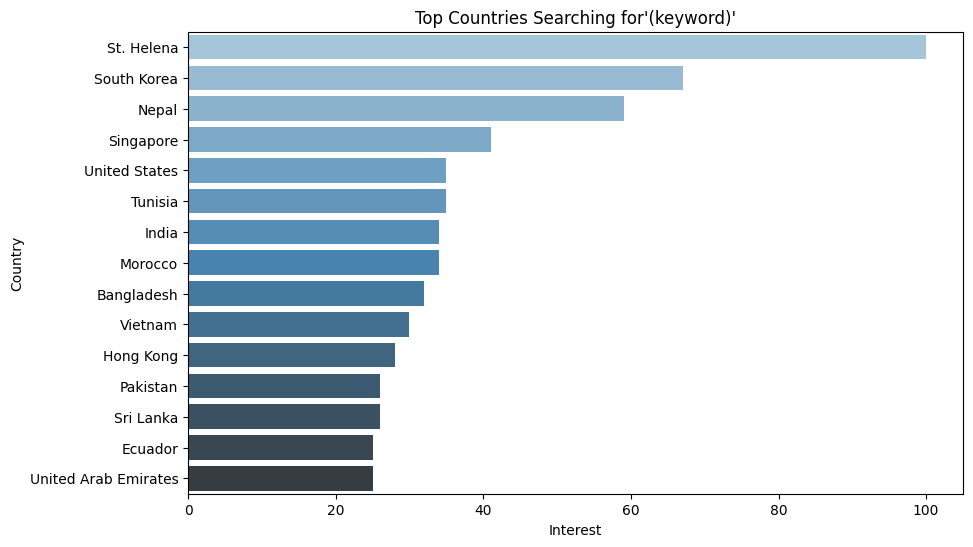

In [30]:
plt.figure(figsize= (10,6))
sns.barplot(x= region_data[keyword], y= region_data.index, palette= 'Blues_d')
plt.title(f"Top Countries Searching for'(keyword)'")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

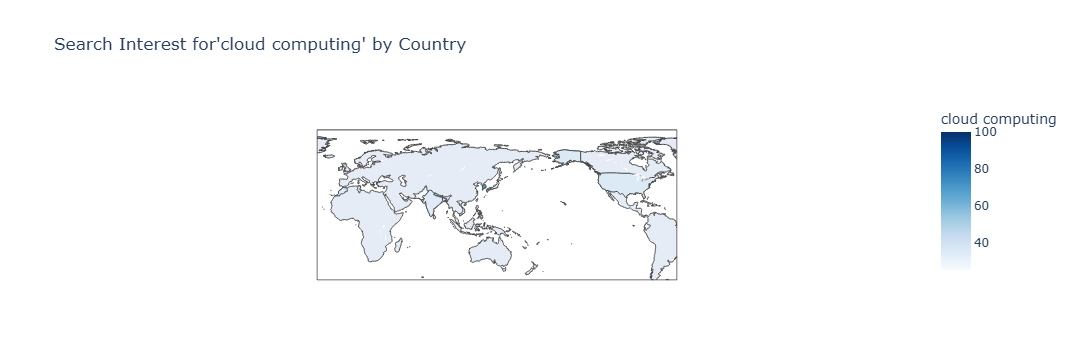

In [33]:
region_data= region_data.reset_index()
fig = px.choropleth(region_data,
                    locations='geoName',
                    locationmode='country names',
                    color= keyword,
                    title= f"Search Interest for'{keyword}' by Country",
                    color_continuous_scale= 'Blues')
fig.show()

In [34]:
#time wise interest

In [35]:
time_df= pytrends.interest_over_time()

In [39]:
import matplotlib.pyplot as plt

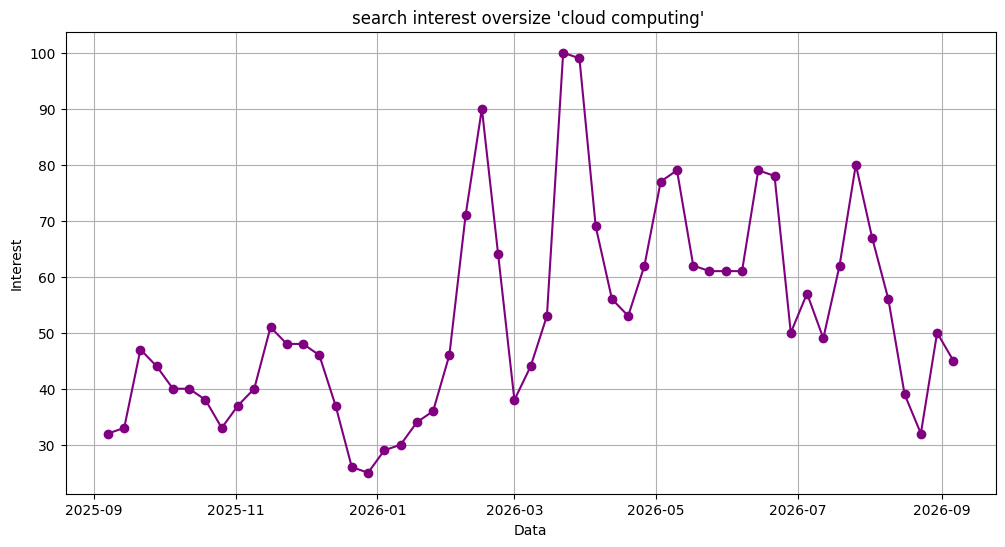

In [43]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker= 'o', color= 'purple')
plt.title(f"search interest oversize '{keyword}' ")
plt.xlabel("Data")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

In [45]:
#multiple keywords compare

In [47]:
kw_list= ["Cloud Computing", "Data Science", "Machine Learning"]
pytrends.build_payload(kw_list, cat= 0, timeframe= 'today 12-m', geo='', gprop='')


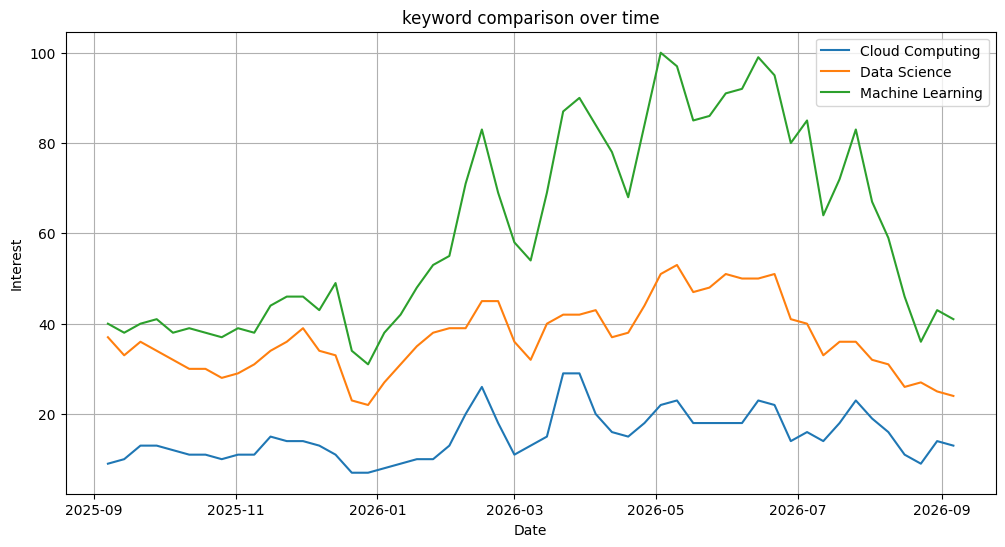

In [52]:
compare_df= pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label= kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.show()